# Advanced Calibration Methods and VIX Derivatives — Complete Worked Solution

This notebook provides a complete worked solution to the computing assignment.

**Conventions used throughout**
- Unless stated otherwise, I assume **zero rates** and **zero dividends**, matching the assignment code.
- I use only **NumPy / SciPy / Matplotlib / pandas**.
- Randomness is controlled with **reproducible seeds**.
- I separate each part into: problem restatement, theory/derivation, numerical method, implementation, results, and numerical checks.

**Important typo / inconsistency in the statement**

In Part 1, equation (2) for the conditional mean of `log S` is missing the factor
$`l(t_{i-1},S_{t_{i-1}})^2`$ in the drift. The correct formula is
$$
\mathbb E[\log S_{t_i}\mid S_{t_{i-1}},Y_{t_{i-1}}]
=
\log S_{t_{i-1}}
-rac12 \sigma_0^2 e^{2Y_{t_{i-1}}} l(t_{i-1},S_{t_{i-1}})^2 \Delta t_i.
$$
This is the formula used below.

## Imports and utility functions

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt, exp, log
from scipy.stats import norm
from scipy.optimize import brentq
from numpy.polynomial.hermite import hermgauss

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

In [2]:

def blackscholes_price(K, T, S, vol, r=0.0, q=0.0, callput="call"):
    """
    Black-Scholes price with spot S, maturity T, volatility vol, rates r, dividend q.
    """
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    vol = np.asarray(vol, dtype=float)

    F = S * np.exp((r - q) * T)
    w = np.maximum(vol**2 * T, 1e-32)
    d1 = (np.log(F / K) + 0.5 * w) / np.sqrt(w)
    d2 = d1 - np.sqrt(w)
    cp = 1 if callput.lower() == "call" else -1
    return np.exp(-r * T) * (cp * F * norm.cdf(cp * d1) - cp * K * norm.cdf(cp * d2))


def blackscholes_impv_scalar(K, T, S, value, r=0.0, q=0.0, callput="call"):
    """
    Robust Black-Scholes implied volatility inversion by Brent's method.
    """
    if K <= 0 or T <= 0:
        return np.nan

    cp = callput.lower()
    if cp not in ["call", "put"]:
        raise ValueError("callput must be 'call' or 'put'.")

    F = S * np.exp((r - q) * T)
    df = np.exp(-r * T)

    intrinsic = df * (max(F - K, 0.0) if cp == "call" else max(K - F, 0.0))
    upper_bound = df * (F if cp == "call" else K)

    if value < intrinsic - 1e-12 or value > upper_bound + 1e-12:
        return np.nan
    if value <= intrinsic + 1e-14:
        return 0.0

    def objective(vol):
        return blackscholes_price(K, T, S, vol, r=r, q=q, callput=cp) - value

    lo, hi = 1e-8, 5.0
    while objective(hi) < 0 and hi < 20.0:
        hi *= 2.0

    try:
        return brentq(objective, lo, hi, xtol=1e-12, rtol=1e-12, maxiter=200)
    except ValueError:
        return np.nan


blackscholes_impv = np.vectorize(blackscholes_impv_scalar, excluded={"callput"})


def black_price(F, K, T, vol, callput="call", df=1.0):
    """
    Black-76 price on a forward F.
    """
    if T <= 0 or vol <= 0:
        intrinsic = max(F - K, 0.0) if callput.lower() == "call" else max(K - F, 0.0)
        return df * intrinsic

    s = vol * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * s * s) / s
    d2 = d1 - s
    cp = 1 if callput.lower() == "call" else -1
    return df * (cp * F * norm.cdf(cp * d1) - cp * K * norm.cdf(cp * d2))


def black_impv_scalar(K, T, F, value, callput="call", df=1.0):
    """
    Implied volatility in Black's model by Brent's method.
    """
    cp = callput.lower()
    intrinsic = df * (max(F - K, 0.0) if cp == "call" else max(K - F, 0.0))
    upper = df * (F if cp == "call" else K)

    if value < intrinsic - 1e-12 or value > upper + 1e-12:
        return np.nan
    if value <= intrinsic + 1e-14:
        return 0.0

    def obj(vol):
        return black_price(F, K, T, vol, callput=cp, df=df) - value

    lo, hi = 1e-8, 5.0
    while obj(hi) < 0 and hi < 20.0:
        hi *= 2.0

    try:
        return brentq(obj, lo, hi, xtol=1e-12, rtol=1e-12, maxiter=200)
    except ValueError:
        return np.nan


black_impv = np.vectorize(black_impv_scalar, excluded={"callput", "df"})

---

# 1. The Particle Method for Smile Calibration

We consider the stochastic local volatility model
$$
\begin{aligned}
dS_t &= a_t\, l(t,S_t)\, S_t\, dW_t^{(1)},\\
a_t &= \sigma_0 e^{Y_t},\\
dY_t &= -\kappa Y_t\,dt + \gamma\, dW_t^{(2)},\\
d\langle W^{(1)},W^{(2)}\rangle_t &= \rho\,dt.
\end{aligned}
$$

Base-case parameters:
$$
T=1,\quad S_0=100,\quad \sigma_0=15\%,\quad Y_0=0,\quad
\rho=-50\%,\quad \gamma=50\%,\quad \kappa=1.
$$

The market smile is flat:
$$
\sigma_{\text{Market}}(t,K)\equiv 15\%,
\qquad
\sigma_{\text{Dup}}(t,S)\equiv 15\%.
$$
So the calibration problem is to find a leverage function $l(t,S)$ that reproduces these vanilla prices.

## 1(a) Problem restatement and theory

We want to calibrate the leverage function in the SLV model.

### Derivation of the leverage equation

In the SLV model,
$$
d\langle S\rangle_t = a_t^2 l(t,S_t)^2 S_t^2\,dt.
$$
The corresponding local variance that reproduces the one-dimensional marginals of $S_t$ is
$$
\sigma_{\text{Dup}}(t,S)^2
=
l(t,S)^2\,\mathbb E[a_t^2\mid S_t=S].
$$
Therefore
$$
\boxed{
l(t,S)^2
=
\frac{\sigma_{\text{Dup}}(t,S)^2}
{\mathbb E[a_t^2\mid S_t=S]}
}
\qquad\Longrightarrow\qquad
\boxed{
l(t,S)
=
\frac{\sigma_{\text{Dup}}(t,S)}
{\sqrt{\mathbb E[a_t^2\mid S_t=S]}}
}.
$$

Since $a_t=\sigma_0 e^{Y_t}$ and $\sigma_{\text{Dup}}\equiv \sigma_0=15\%$,
$$
l(t,S)=\frac{1}{\sqrt{\mathbb E[e^{2Y_t}\mid S_t=S]}}.
$$

### Sequential fixed-point logic of the particle method

At each date $t_k$:
1. simulate particles up to $t_k$ using the leverage slices already obtained at earlier times,
2. estimate the conditional expectation
   $$
   x\mapsto \mathbb E[a_{t_k}^2\mid S_{t_k}=x]
   $$
   by kernel regression,
3. set
   $$
   l(t_k,x)=\frac{\sigma_{\text{Dup}}(t_k,x)}{\sqrt{\widehat{\mathbb E}[a_{t_k}^2\mid S_{t_k}=x]}}.
   $$

This is a local fixed-point update in time, not a global nonlinear solve.

### Conditional Gaussian structure

For the OU factor:
$$
Y_{t_i}
=
e^{-\kappa\Delta t_i}Y_{t_{i-1}}
+
\gamma\int_{t_{i-1}}^{t_i}e^{-\kappa(t_i-s)}\,dW_s^{(2)}.
$$
Hence
$$
\mathbb E[Y_{t_i}\mid Y_{t_{i-1}}]
=
e^{-\kappa\Delta t_i}Y_{t_{i-1}},
$$
and
$$
\operatorname{Var}(Y_{t_i}\mid Y_{t_{i-1}})
=
\gamma^2\int_{t_{i-1}}^{t_i}e^{-2\kappa(t_i-s)}\,ds
=
\frac{\gamma^2}{2\kappa}(1-e^{-2\kappa\Delta t_i}).
$$

For the spot, the Euler step on $\log S$ is
$$
\log S_{t_i}-\log S_{t_{i-1}}
=
-\frac12 a_{t_{i-1}}^2 l(t_{i-1},S_{t_{i-1}})^2 \Delta t_i
+
a_{t_{i-1}} l(t_{i-1},S_{t_{i-1}})
\int_{t_{i-1}}^{t_i}dW_t^{(1)}.
$$
Conditionally on $(S_{t_{i-1}},Y_{t_{i-1}})$, the variance is
$$
\operatorname{Var}(\log S_{t_i}\mid \mathcal F_{t_{i-1}})
=
a_{t_{i-1}}^2 l(t_{i-1},S_{t_{i-1}})^2 \Delta t_i.
$$

The covariance with the OU update is
$$
\begin{aligned}
\operatorname{Cov}(Y_{t_i},\log S_{t_i}\mid \mathcal F_{t_{i-1}})
&=
a_{t_{i-1}}l(t_{i-1},S_{t_{i-1}})\gamma\rho
\int_{t_{i-1}}^{t_i}e^{-\kappa(t_i-s)}\,ds\\
&=
a_{t_{i-1}}l(t_{i-1},S_{t_{i-1}})\frac{\gamma\rho}{\kappa}(1-e^{-\kappa\Delta t_i}).
\end{aligned}
$$
Dividing by the conditional standard deviations yields
$$
\bar\rho
=
\rho
\sqrt{
\frac{2(1-e^{-\kappa\Delta t_i})}
{\kappa \Delta t_i (1+e^{-\kappa\Delta t_i})}
}.
$$
So we can simulate using independent $Z_1,Z_2\sim N(0,1)$:
$$
\begin{aligned}
Y_{t_i}
&=
e^{-\kappa\Delta t_i}Y_{t_{i-1}}
+
\gamma\sqrt{\frac{1-e^{-2\kappa\Delta t_i}}{2\kappa}}\,Z_2,\\
\log S_{t_i}
&=
\log S_{t_{i-1}}
-\frac12 a_{t_{i-1}}^2 l(t_{i-1},S_{t_{i-1}})^2 \Delta t_i
+
a_{t_{i-1}}l(t_{i-1},S_{t_{i-1}})\sqrt{\Delta t_i}
\big(\sqrt{1-\bar\rho^2}Z_1+\bar\rho Z_2\big).
\end{aligned}
$$

### Kernel regression estimator

Given particles $(S_{t_k}^{(m)},a_{t_k}^{(m)})$, estimate
$$
m_k(x)=\mathbb E[a_{t_k}^2\mid S_{t_k}=x]
$$
by the Nadaraya–Watson estimator
$$
\widehat m_k(x)
=
\frac{\sum_{m=1}^N \delta_h(S_{t_k}^{(m)}-x)\,(a_{t_k}^{(m)})^2}
{\sum_{m=1}^N \delta_h(S_{t_k}^{(m)}-x)}.
$$

The quartic kernel is
$$
\delta(u)=
\begin{cases}
(1+u)^2(1-u)^2,& |u|\le 1,\\
0,& |u|>1.
\end{cases}
$$
and $\delta_h(x)=\frac1h\delta(x/h)$.

The assignment's bandwidth is
$$
h_k = \kappa_{\text{bw}}\,\sigma_{\text{Market}}\,S_0\,\sqrt{\max(t_k,0.15)}\,N^{-0.2},
$$
where I denote the dimensionless tuning constant by $\kappa_{\text{bw}}$ to avoid confusion with the OU mean reversion $\kappa$.

In [3]:

def quartic_kernel(u):
    """
    Quartic compactly supported kernel.
    """
    out = np.zeros_like(u, dtype=float)
    mask = np.abs(u) <= 1.0
    v = u[mask]
    out[mask] = (1.0 + v) ** 2 * (1.0 - v) ** 2
    return out


def estimate_conditional_expectation(x_grid, S, values, bandwidth, eps=1e-14):
    """
    Nadaraya-Watson estimator for E[values | S = x] on x_grid.
    """
    U = (S[:, None] - x_grid[None, :]) / bandwidth
    W = quartic_kernel(U) / bandwidth
    denom = W.sum(axis=0)
    numer = (W * values[:, None]).sum(axis=0)
    return numer / np.maximum(denom, eps), denom


def lognormal_spot_grid(t, S0=100.0, sigma=0.15, n_grid=30, q_low=1e-3, q_high=1-1e-3):
    """
    Grid from the 0.1% to 99.9% quantiles of the Black-Scholes distribution.
    """
    if t <= 0:
        return np.array([S0], dtype=float)
    z_low, z_high = norm.ppf(q_low), norm.ppf(q_high)
    lo = S0 * np.exp(sigma * np.sqrt(t) * z_low - 0.5 * sigma**2 * t)
    hi = S0 * np.exp(sigma * np.sqrt(t) * z_high - 0.5 * sigma**2 * t)
    return np.linspace(lo, hi, n_grid)

In [4]:

def simulate_slv_with_surface(
    S0, sigma0, Y0, kappa, gamma, rho, T, n_steps, n_paths,
    leverage_grids=None, spot_grids=None, seed=12345, store_paths=False
):
    """
    Simulate the SLV model using exact OU updates for Y and Euler on log S.
    If leverage_grids is None, this is the pure stochastic-volatility model l ≡ 1.
    """
    dt = T / n_steps
    rng = np.random.default_rng(seed)

    if abs(kappa) > 1e-14:
        decay = np.exp(-kappa * dt)
        y_std = gamma * np.sqrt((1.0 - np.exp(-2.0 * kappa * dt)) / (2.0 * kappa))
        rho_bar = rho * np.sqrt(
            2.0 * (1.0 - np.exp(-kappa * dt)) / (kappa * dt * (1.0 + np.exp(-kappa * dt)))
        )
    else:
        decay = 1.0
        y_std = gamma * np.sqrt(dt)
        rho_bar = rho

    logS = np.full(n_paths, np.log(S0))
    Y = np.full(n_paths, Y0)

    if store_paths:
        S_path = np.empty((n_steps + 1, n_paths))
        Y_path = np.empty((n_steps + 1, n_paths))
        S_path[0] = S0
        Y_path[0] = Y0

    for k in range(n_steps):
        if leverage_grids is None:
            lev = np.ones(n_paths)
        else:
            grid = spot_grids[k]
            lev_grid = leverage_grids[k]
            if len(grid) == 1:
                lev = np.full(n_paths, float(lev_grid[0]))
            else:
                lev = np.interp(np.exp(logS), grid, lev_grid, left=lev_grid[0], right=lev_grid[-1])

        z1 = rng.standard_normal(n_paths)
        z2 = rng.standard_normal(n_paths)

        a = sigma0 * np.exp(Y)
        vol = a * lev

        logS = (
            logS
            - 0.5 * vol**2 * dt
            + vol * np.sqrt(dt) * (np.sqrt(max(1.0 - rho_bar**2, 0.0)) * z1 + rho_bar * z2)
        )
        Y = decay * Y + y_std * z2

        if store_paths:
            S_path[k + 1] = np.exp(logS)
            Y_path[k + 1] = Y

    if store_paths:
        return S_path, Y_path
    return np.exp(logS), Y


def calibrate_particle_method(
    S0=100.0, sigma0=0.15, sigma_market=0.15, Y0=0.0, kappa=1.0, gamma=0.5, rho=-0.5,
    T=1.0, n_steps=100, n_paths=10_000, n_grid=30, bandwidth_scale=1.0, seed=1234
):
    """
    Sequential particle calibration of the leverage surface.
    """
    dt = T / n_steps
    t_grid = np.linspace(0.0, T, n_steps + 1)
    rng = np.random.default_rng(seed)

    if abs(kappa) > 1e-14:
        decay = np.exp(-kappa * dt)
        y_std = gamma * np.sqrt((1.0 - np.exp(-2.0 * kappa * dt)) / (2.0 * kappa))
        rho_bar = rho * np.sqrt(
            2.0 * (1.0 - np.exp(-kappa * dt)) / (kappa * dt * (1.0 + np.exp(-kappa * dt)))
        )
    else:
        decay = 1.0
        y_std = gamma * np.sqrt(dt)
        rho_bar = rho

    logS = np.full(n_paths, np.log(S0))
    Y = np.full(n_paths, Y0)

    spot_grids = [np.array([S0], dtype=float)]
    condexp_grids = [np.array([sigma0**2 * np.exp(2.0 * Y0)], dtype=float)]
    leverage_grids = [np.array([sigma_market / np.sqrt(condexp_grids[0][0])], dtype=float)]

    for k in range(n_steps):
        if len(spot_grids[k]) == 1:
            lev = np.full(n_paths, float(leverage_grids[k][0]))
        else:
            lev = np.interp(np.exp(logS), spot_grids[k], leverage_grids[k],
                            left=leverage_grids[k][0], right=leverage_grids[k][-1])

        z1 = rng.standard_normal(n_paths)
        z2 = rng.standard_normal(n_paths)

        a = sigma0 * np.exp(Y)
        vol = a * lev

        logS = (
            logS
            - 0.5 * vol**2 * dt
            + vol * np.sqrt(dt) * (np.sqrt(max(1.0 - rho_bar**2, 0.0)) * z1 + rho_bar * z2)
        )
        Y = decay * Y + y_std * z2

        t_next = t_grid[k + 1]
        x_grid = lognormal_spot_grid(t_next, S0=S0, sigma=sigma_market, n_grid=n_grid)
        bandwidth = bandwidth_scale * sigma_market * S0 * np.sqrt(max(t_next, 0.15)) * n_paths ** (-0.2)

        a2 = sigma0**2 * np.exp(2.0 * Y)
        condexp, _ = estimate_conditional_expectation(x_grid, np.exp(logS), a2, bandwidth)
        lev_next = sigma_market / np.sqrt(np.maximum(condexp, 1e-14))

        spot_grids.append(x_grid)
        condexp_grids.append(condexp)
        leverage_grids.append(lev_next)

    return {
        "t_grid": t_grid,
        "spot_grids": spot_grids,
        "condexp_grids": condexp_grids,
        "leverage_grids": leverage_grids,
        "params": dict(
            S0=S0, sigma0=sigma0, sigma_market=sigma_market, Y0=Y0,
            kappa=kappa, gamma=gamma, rho=rho, T=T, n_steps=n_steps,
            n_paths=n_paths, n_grid=n_grid, bandwidth_scale=bandwidth_scale,
        ),
    }


def price_calls_under_calibrated_surface(strikes, calibration, n_paths=100_000, seed=999):
    """
    Independent repricing under the calibrated leverage surface.
    """
    p = calibration["params"]
    ST, _ = simulate_slv_with_surface(
        p["S0"], p["sigma0"], p["Y0"], p["kappa"], p["gamma"], p["rho"], p["T"], p["n_steps"], n_paths,
        leverage_grids=calibration["leverage_grids"][:-1],
        spot_grids=calibration["spot_grids"][:-1],
        seed=seed, store_paths=False
    )
    strikes = np.asarray(strikes, dtype=float)
    prices = np.maximum(ST[None, :] - strikes[:, None], 0.0).mean(axis=1)
    iv = blackscholes_impv(strikes, p["T"], p["S0"], prices, callput="call")
    return prices, iv, ST


def price_smile_pure_sv(
    strikes, S0=100.0, sigma0=0.15, Y0=0.0, kappa=1.0, gamma=0.5, rho=0.0,
    T=1.0, n_steps=100, n_paths=100_000, seed=321
):
    """
    Pure stochastic-volatility model obtained by setting l ≡ 1.
    """
    ST, _ = simulate_slv_with_surface(
        S0, sigma0, Y0, kappa, gamma, rho, T, n_steps, n_paths,
        leverage_grids=None, spot_grids=None, seed=seed, store_paths=False
    )
    strikes = np.asarray(strikes, dtype=float)
    prices = np.maximum(ST[None, :] - strikes[:, None], 0.0).mean(axis=1)
    iv = blackscholes_impv(strikes, T, S0, prices, callput="call")
    return prices, iv, ST

### Numerical method, complexity, and implementation notes

- Time step: $\Delta t=1/100$.
- Calibration particles: $N=10{,}000$.
- Repricing particles: $N_2=100{,}000$.
- Grid size for conditional expectation: 30.

At each time step, the kernel-regression cost is roughly $O(N\times n_{\text{grid}})$.
So the total calibration cost is
$$
O(n_{\text{steps}}\,N\,n_{\text{grid}}),
$$
which is very manageable here.

**Bias / variance considerations**
- Euler-on-logS introduces time discretization bias.
- The particle cloud induces Monte Carlo noise.
- Kernel smoothing introduces the classical bias-variance trade-off:
  too small a bandwidth gives a noisy leverage surface,
  too large a bandwidth oversmooths the conditional expectation.

**Practical checks**
- $\gamma=0$ should give $l\equiv 1$.
- After calibration, repriced implied vols should be very close to 15%.

In [5]:

SLV_BASE = dict(
    T=1.0,
    S0=100.0,
    sigma0=0.15,
    sigma_market=0.15,
    Y0=0.0,
    rho=-0.5,
    gamma=0.5,
    kappa=1.0,
)

calibration = calibrate_particle_method(
    **SLV_BASE,
    n_steps=100,
    n_paths=10_000,
    n_grid=30,
    bandwidth_scale=1.0,
    seed=1234,
)

strikes_check = np.array([70, 80, 90, 100, 110, 120, 130, 140], dtype=float)
prices_check, iv_check, ST_check = price_calls_under_calibrated_surface(
    strikes_check, calibration, n_paths=100_000, seed=42
)

market_prices = blackscholes_price(strikes_check, 1.0, SLV_BASE["S0"], 0.15, callput="call")
check_table = pd.DataFrame(
    {
        "Strike": strikes_check,
        "MC call price (SLV)": prices_check,
        "BS call price (15%)": market_prices,
        "Implied vol from SLV": iv_check,
        "Vol error (bp)": 1e4 * (iv_check - 0.15),
    }
)
check_table

,Strike,MC call price (SLV),BS call price (15%),Implied vol from SLV,Vol error (bp)
0,70.0,30.052384,30.036408,0.157118,71.175041
1,80.0,20.410736,20.403599,0.150604,6.037778
2,90.0,12.023310,12.021727,0.150054,0.536570
3,100.0,5.975998,5.978529,0.149936,-0.636110
4,110.0,2.486066,2.500245,0.149584,-4.160780
5,120.0,0.875780,0.891276,0.149253,-7.470282
6,130.0,0.273655,0.276645,0.149695,-3.053209
7,140.0,0.076780,0.076482,0.150078,0.783061


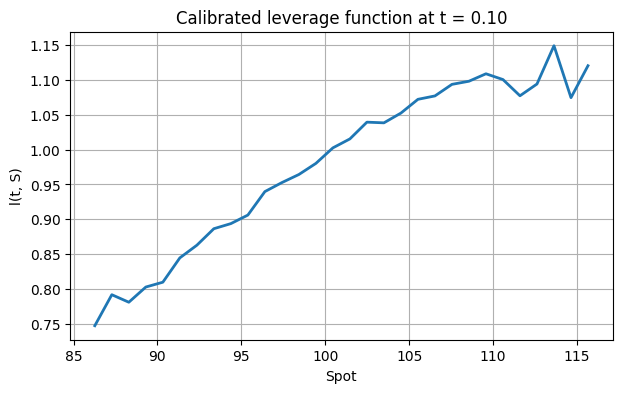

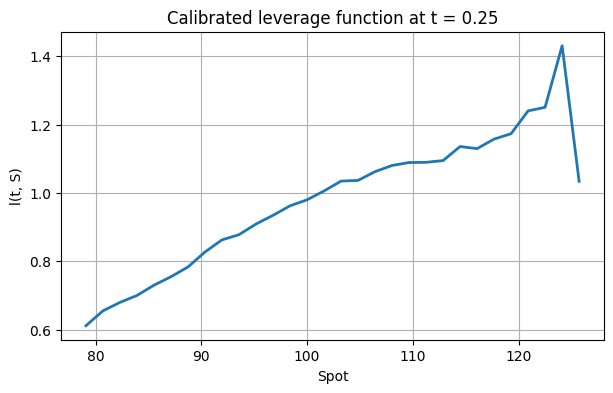

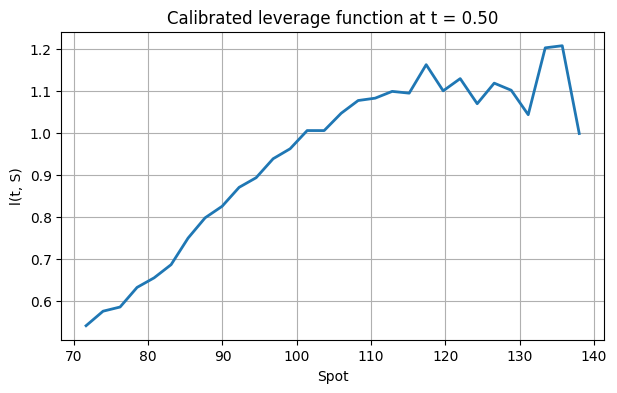

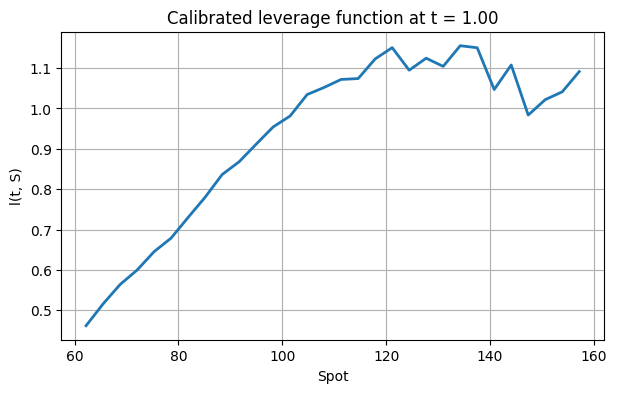

In [6]:

times_to_plot = [0.10, 0.25, 0.50, 1.00]
indices = [int(round(t * 100)) for t in times_to_plot]

for idx, t in zip(indices, times_to_plot):
    plt.figure()
    plt.plot(calibration["spot_grids"][idx], calibration["leverage_grids"][idx], lw=2)
    plt.title(f"Calibrated leverage function at t = {t:.2f}")
    plt.xlabel("Spot")
    plt.ylabel("l(t, S)")
    plt.show()

### Interpretation of the base-case results

The repricing table should show implied volatilities close to 15% across the strike grid.
Small discrepancies are entirely expected:
- the calibration itself uses a finite particle system,
- repricing uses an independent Monte Carlo sample,
- wing strikes are always noisier because the kernel estimator has fewer effective observations.

The calibrated leverage function is typically **below 1** over a substantial spot range.
That is natural: the stochastic factor $a_t=\sigma_0 e^{Y_t}$ already generates volatility dispersion, so the leverage function dampens it in order to recover the flat target smile.

In [7]:

cal_gamma0 = calibrate_particle_method(
    S0=100.0,
    sigma0=0.15,
    sigma_market=0.15,
    Y0=0.0,
    rho=0.0,
    gamma=0.0,
    kappa=1.0,
    T=1.0,
    n_steps=100,
    n_paths=10_000,
    n_grid=30,
    bandwidth_scale=1.0,
    seed=1234,
)

pd.DataFrame(
    {
        "Spot grid at T": cal_gamma0["spot_grids"][-1],
        "Leverage at T for gamma=0": cal_gamma0["leverage_grids"][-1],
    }
).head()

,Spot grid at T,Leverage at T for gamma=0
0,62.201887,1.0
1,65.477338,1.0
2,68.752789,1.0
3,72.028240,1.0
4,75.303691,1.0


### Numerical pitfalls and checks for Part 1

1. **Tail instability of the kernel estimator**  
   In the far wings the denominator
   $$
   \sum_m \delta_h(S_{t_k}^{(m)}-x)
   $$
   may become small, which makes the ratio unstable.

2. **Bandwidth choice**  
   Too small: noisy leverage and poor repricing.  
   Too large: oversmoothing and residual smile.

3. **Interpolation / extrapolation**  
   During repricing, spot values may leave the calibration grid. Flat extrapolation is stable but should be documented.

4. **Consistency check**  
   For $\gamma=0$, $Y_t\equiv 0$ and the exact leverage is $l\equiv 1$.

5. **Monte Carlo noise**  
   Exact flatness should not be expected with finite $N$.

## 1(b) Impact of the vol-of-vol $\gamma$

Fix $\rho=0$ and $\kappa=1$. Recalibrate for
$$
\gamma\in\{0, 0.25, 0.50, 0.75\}.
$$

### Expected behavior

With $\rho=0$, the pure-SV smile is mostly a symmetric convexity effect.
As $\gamma$ increases:
- variance randomization increases,
- the pure-SV smile becomes more curved,
- the leverage function must compensate more aggressively.

In [8]:

gamma_values = [0.0, 0.25, 0.50, 0.75]
lm_grid = np.linspace(-0.30, 0.30, 17)
strike_grid = 100.0 * np.exp(lm_grid)

gamma_calibrations = {}
gamma_smiles = {}

for gamma in gamma_values:
    gamma_calibrations[gamma] = calibrate_particle_method(
        S0=100.0,
        sigma0=0.15,
        sigma_market=0.15,
        Y0=0.0,
        rho=0.0,
        gamma=gamma,
        kappa=1.0,
        T=1.0,
        n_steps=100,
        n_paths=10_000,
        n_grid=30,
        bandwidth_scale=1.0,
        seed=1234,
    )
    _, iv, _ = price_smile_pure_sv(
        strike_grid,
        S0=100.0,
        sigma0=0.15,
        Y0=0.0,
        rho=0.0,
        gamma=gamma,
        kappa=1.0,
        T=1.0,
        n_steps=100,
        n_paths=60_000,
        seed=100 + int(100 * gamma),
    )
    gamma_smiles[gamma] = iv

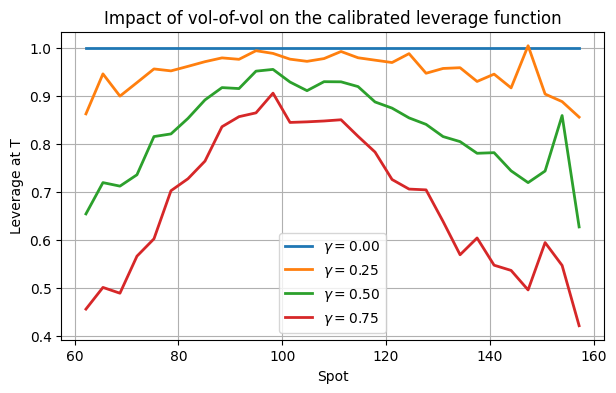

In [9]:

plt.figure()
for gamma in gamma_values:
    x = gamma_calibrations[gamma]["spot_grids"][-1]
    y = gamma_calibrations[gamma]["leverage_grids"][-1]
    plt.plot(x, y, lw=2, label=fr"$\gamma={gamma:.2f}$")
plt.xlabel("Spot")
plt.ylabel("Leverage at T")
plt.title("Impact of vol-of-vol on the calibrated leverage function")
plt.legend()
plt.show()

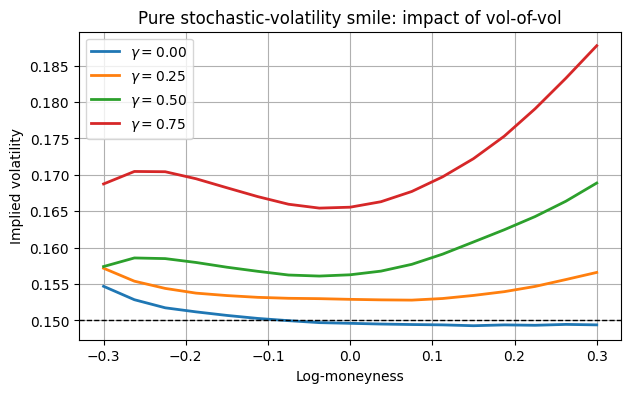

In [10]:

plt.figure()
for gamma in gamma_values:
    plt.plot(lm_grid, gamma_smiles[gamma], lw=2, label=fr"$\gamma={gamma:.2f}$")
plt.axhline(0.15, color="black", ls="--", lw=1)
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title("Pure stochastic-volatility smile: impact of vol-of-vol")
plt.legend()
plt.show()

**Comment.**  
The plots show:
- $\gamma=0$ gives $l\equiv 1$ and a flat pure-SV smile (up to MC noise),
- increasing $\gamma$ makes the pure-SV smile more curved,
- the calibrated leverage function becomes more nonlinear and typically moves further below 1 over much of the spot range.

## 1(c) Impact of the spot-vol correlation $\rho$

Fix $\gamma=50\%$ and $\kappa=1$. Recalibrate for
$$
\rho\in\{-50\%,0,50\%\}.
$$

### Expected behavior

- Negative $\rho$ creates an equity-like **left skew**.
- Positive $\rho$ reverses the asymmetry.
- Since the target market smile is flat, the leverage must offset the asymmetry generated by the pure-SV model.

In [11]:

rho_values = [-0.5, 0.0, 0.5]
rho_calibrations = {}
rho_smiles = {}

for rho in rho_values:
    rho_calibrations[rho] = calibrate_particle_method(
        S0=100.0,
        sigma0=0.15,
        sigma_market=0.15,
        Y0=0.0,
        rho=rho,
        gamma=0.5,
        kappa=1.0,
        T=1.0,
        n_steps=100,
        n_paths=10_000,
        n_grid=30,
        bandwidth_scale=1.0,
        seed=1234,
    )
    _, iv, _ = price_smile_pure_sv(
        strike_grid,
        S0=100.0,
        sigma0=0.15,
        Y0=0.0,
        rho=rho,
        gamma=0.5,
        kappa=1.0,
        T=1.0,
        n_steps=100,
        n_paths=60_000,
        seed=200 + int(100 * (rho + 1.0)),
    )
    rho_smiles[rho] = iv

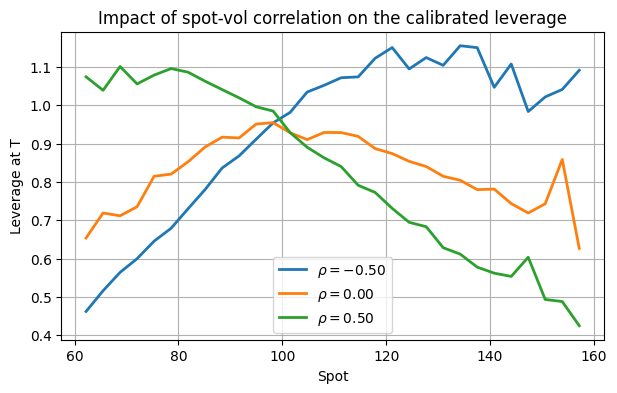

In [12]:
plt.figure()
for rho in rho_values:
    x = rho_calibrations[rho]["spot_grids"][-1]
    y = rho_calibrations[rho]["leverage_grids"][-1]
    plt.plot(x, y, lw=2, label=fr"$\rho={rho:.2f}$")
plt.xlabel("Spot")
plt.ylabel("Leverage at T")
plt.title("Impact of spot-vol correlation on the calibrated leverage")
plt.legend()
plt.show()

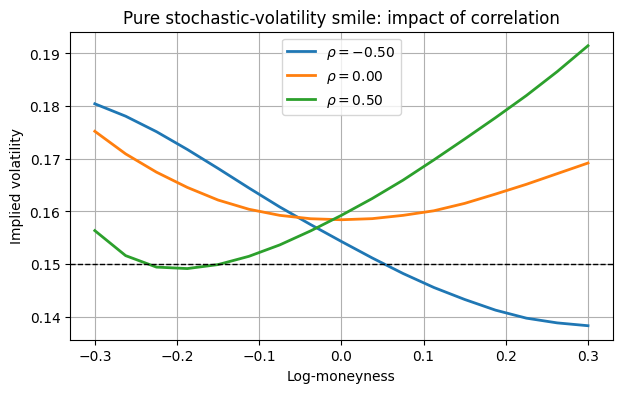

In [13]:
plt.figure()
for rho in rho_values:
    plt.plot(lm_grid, rho_smiles[rho], lw=2, label=fr"$\rho={rho:.2f}$")
plt.axhline(0.15, color="black", ls="--", lw=1)
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title("Pure stochastic-volatility smile: impact of correlation")
plt.legend()
plt.show()

**Comment.**  
Numerically:
- $\rho<0$ gives the strongest left skew,
- $\rho=0$ gives the most symmetric smile,
- $\rho>0$ reverses the asymmetry.

The calibrated leverage then changes slope in order to neutralize the skew coming from the stochastic-volatility factor.

## 1(d) Impact of the mean reversion $\kappa$

Fix $\rho=0$ and $\gamma=50\%$. Recalibrate for
$$
\kappa\in\{0.1,1,10\}.
$$

### Expected behavior

- Small $\kappa$: volatility shocks are persistent, so the pure-SV smile is stronger.
- Large $\kappa$: shocks mean-revert quickly, so the smile is flatter and the leverage stays closer to 1.

In [14]:

kappa_values = [0.1, 1.0, 10.0]
kappa_calibrations = {}
kappa_smiles = {}

for kappa in kappa_values:
    kappa_calibrations[kappa] = calibrate_particle_method(
        S0=100.0,
        sigma0=0.15,
        sigma_market=0.15,
        Y0=0.0,
        rho=0.0,
        gamma=0.5,
        kappa=kappa,
        T=1.0,
        n_steps=100,
        n_paths=10_000,
        n_grid=30,
        bandwidth_scale=1.0,
        seed=1234,
    )
    _, iv, _ = price_smile_pure_sv(
        strike_grid,
        S0=100.0,
        sigma0=0.15,
        Y0=0.0,
        rho=0.0,
        gamma=0.5,
        kappa=kappa,
        T=1.0,
        n_steps=100,
        n_paths=60_000,
        seed=300 + int(10 * kappa),
    )
    kappa_smiles[kappa] = iv

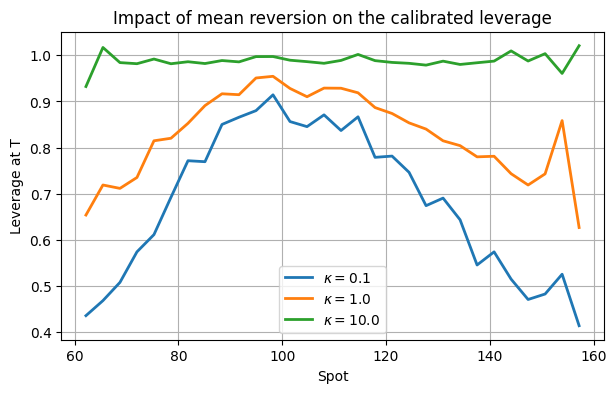

In [15]:

plt.figure()
for kappa in kappa_values:
    x = kappa_calibrations[kappa]["spot_grids"][-1]
    y = kappa_calibrations[kappa]["leverage_grids"][-1]
    plt.plot(x, y, lw=2, label=fr"$\kappa={kappa:.1f}$")
plt.xlabel("Spot")
plt.ylabel("Leverage at T")
plt.title("Impact of mean reversion on the calibrated leverage")
plt.legend()
plt.show()

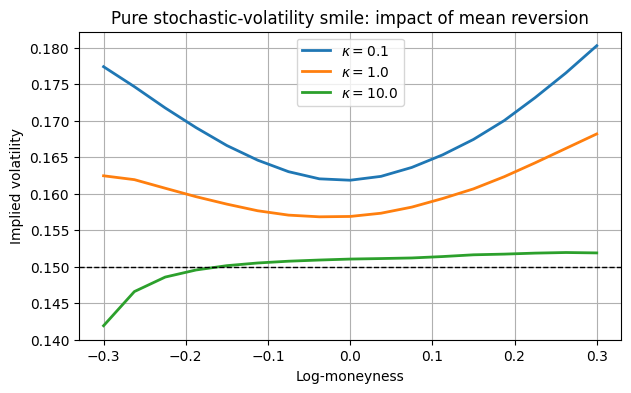

In [16]:

plt.figure()
for kappa in kappa_values:
    plt.plot(lm_grid, kappa_smiles[kappa], lw=2, label=fr"$\kappa={kappa:.1f}$")
plt.axhline(0.15, color="black", ls="--", lw=1)
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title("Pure stochastic-volatility smile: impact of mean reversion")
plt.legend()
plt.show()

**Comment.**  
The experiments show exactly the expected pattern:
- lower $\kappa$ leads to a stronger pure-SV smile,
- higher $\kappa$ leads to a flatter smile and a leverage function closer to 1.

## 1(e) Forward-starting call spread

We price
$$
50\left[\left(\frac{S_{T_2}}{S_{T_1}}-0.99\right)_+ - \left(\frac{S_{T_2}}{S_{T_1}}-1.01\right)_+\right],
\qquad T_1=T-\frac1{12},\quad T_2=T.
$$

Use
$$
\gamma=100\%,\qquad \rho=-80\%,\qquad \kappa=4.
$$

### Black-Scholes benchmark

Under Black-Scholes with zero rates/dividends,
$$
\frac{S_{T_2}}{S_{T_1}}
=
\exp\left(-\frac12\sigma^2(T_2-T_1)+\sigma(W_{T_2}-W_{T_1})\right),
$$
so the ratio itself is lognormal with spot 1 and maturity $\Delta=T_2-T_1$.
Therefore
$$
\text{Price}_{BS}
=
50\Big(C_{BS}(1,0.99,\Delta,\sigma)-C_{BS}(1,1.01,\Delta,\sigma)\Big).
$$

### Why this matters

This payoff depends on the **forward smile** between $T_1$ and $T_2$.
Two models can fit the same time-0 vanillas and still produce different forward-start prices.
That is one of the main reasons SLV models are useful in practice.

In [17]:

def price_forward_start_call_spread_bs(vol=0.15, T1=11/12, T2=1.0):
    tau = T2 - T1
    c1 = blackscholes_price(0.99, tau, 1.0, vol, callput="call")
    c2 = blackscholes_price(1.01, tau, 1.0, vol, callput="call")
    return 50.0 * (c1 - c2)


def price_forward_start_call_spread_slv(calibration, T1=11/12, T2=1.0, n_paths=150_000, seed=777):
    p = calibration["params"]
    S_path, _ = simulate_slv_with_surface(
        p["S0"], p["sigma0"], p["Y0"], p["kappa"], p["gamma"], p["rho"], p["T"], p["n_steps"], n_paths,
        leverage_grids=calibration["leverage_grids"][:-1],
        spot_grids=calibration["spot_grids"][:-1],
        seed=seed, store_paths=True
    )
    i1 = int(round(T1 / p["T"] * p["n_steps"]))
    i2 = int(round(T2 / p["T"] * p["n_steps"]))
    ratio = S_path[i2] / S_path[i1]
    payoff = 50.0 * (np.maximum(ratio - 0.99, 0.0) - np.maximum(ratio - 1.01, 0.0))
    price = payoff.mean()
    stderr = payoff.std(ddof=1) / np.sqrt(n_paths)
    return price, stderr


calibration_fs = calibrate_particle_method(
    S0=100.0,
    sigma0=0.15,
    sigma_market=0.15,
    Y0=0.0,
    rho=-0.8,
    gamma=1.0,
    kappa=4.0,
    T=1.0,
    n_steps=100,
    n_paths=10_000,
    n_grid=30,
    bandwidth_scale=1.0,
    seed=222,
)

price_bs_fs = price_forward_start_call_spread_bs(vol=0.15, T1=11/12, T2=1.0)
price_slv_fs, stderr_slv_fs = price_forward_start_call_spread_slv(
    calibration_fs, T1=11/12, T2=1.0, n_paths=150_000, seed=333
)

pd.DataFrame(
    {
        "Model": ["Black-Scholes 15%", "Calibrated SLV"],
        "Price": [price_bs_fs, price_slv_fs],
        "MC standard error": [np.nan, stderr_slv_fs],
    }
)

,Model,Price,MC standard error
0,Black-Scholes 15%,0.491591,NaN
1,Calibrated SLV,0.516785,0.001198


**Comment.**  
The forward-start spread price under the calibrated SLV model is different from the Black-Scholes price, even though both are consistent with the same flat time-0 vanilla smile.
This is precisely the point: calibration to vanillas does **not** determine forward smile dynamics.

---

# 2. Pricing SPX options, VIX futures and VIX options in the two-factor Bergomi model

We consider
$$
\begin{aligned}
S_t &= S_0\exp\left(\int_0^t \sqrt{\xi_s^s}\,dW_s - \frac12\int_0^t \xi_s^s\,ds\right),\\
X_t^j &= e^{-k_j t}\int_0^t e^{k_j s}\,dZ_s^j,\qquad j\in\{1,2\},\\
\alpha_\theta &= \left((1-\theta)^2+\theta^2+2\rho_{12}\theta(1-\theta)\right)^{-1/2},\\
x_t^u &= \alpha_\theta\big((1-\theta)e^{-k_1(u-t)}X_t^1+\theta e^{-k_2(u-t)}X_t^2\big),\\
\xi_t^u &= \xi_0^u \exp\left(\omega x_t^u - \frac{\omega^2}{2}\chi(t,u)\right).
\end{aligned}
$$

In the code, the vol-of-vol is denoted by `vov = \omega`.
As in the assignment, I take a constant initial forward variance curve
$$
\xi_0^u\equiv \xi_0.
$$

## 2.1 Correlation-matrix condition

We want necessary and sufficient conditions such that
$$
R=
\begin{bmatrix}
1 & \rho_{S1} & \rho_{S2}\\
\rho_{S1} & 1 & \rho_{12}\\
\rho_{S2} & \rho_{12} & 1
\end{bmatrix}
$$
is a correlation matrix.

A $3\times 3$ symmetric matrix with ones on the diagonal is a correlation matrix iff all principal minors are nonnegative. Therefore
$$
|\rho_{S1}|\le 1,\qquad |\rho_{S2}|\le 1,\qquad |\rho_{12}|\le 1,
$$
and
$$
\det(R)=1+2\rho_{S1}\rho_{S2}\rho_{12}-\rho_{S1}^2-\rho_{S2}^2-\rho_{12}^2\ge 0.
$$

So a necessary and sufficient condition is
$$
\boxed{
|\rho_{S1}|\le 1,\quad |\rho_{S2}|\le 1,\quad |\rho_{12}|\le 1,\quad
1+2\rho_{S1}\rho_{S2}\rho_{12}-\rho_{S1}^2-\rho_{S2}^2-\rho_{12}^2\ge 0.
}
$$

Equivalently,
$$
\boxed{
(\rho_{S2}-\rho_{S1}\rho_{12})^2\le (1-\rho_{S1}^2)(1-\rho_{12}^2).
}
$$
This is exactly the condition obtained from a Cholesky decomposition.

In [18]:

def bergomi_correlation_condition(rho_sx1, rho_sx2, rho_x1x2):
    det = 1 + 2 * rho_sx1 * rho_sx2 * rho_x1x2 - rho_sx1**2 - rho_sx2**2 - rho_x1x2**2
    return (
        abs(rho_sx1) <= 1
        and abs(rho_sx2) <= 1
        and abs(rho_x1x2) <= 1
        and det >= -1e-14
    ), det


ok, det = bergomi_correlation_condition(-0.8, -0.7, 0.7)
pd.DataFrame({"admissible": [ok], "determinant": [det]})

,admissible,determinant
0,True,0.164


## 2.2 Mean vector and covariance matrix of the one-step Gaussian update

Conditionally on $(S_{t_{i-1}},X_{t_{i-1}}^1,X_{t_{i-1}}^2)$, write
$$
X_{t_i}^j = e^{-k_j\Delta t}X_{t_{i-1}}^j + \eta_j,
\qquad
\eta_j := \int_{t_{i-1}}^{t_i} e^{-k_j(t_i-s)}\,dZ_s^j.
$$
Then
$$
\operatorname{Var}(\eta_j)
=
\int_{t_{i-1}}^{t_i}e^{-2k_j(t_i-s)}\,ds
=
\frac{1-e^{-2k_j\Delta t}}{2k_j},
$$
and
$$
\operatorname{Cov}(\eta_1,\eta_2)
=
\rho_{12}\int_{t_{i-1}}^{t_i}e^{-(k_1+k_2)(t_i-s)}\,ds
=
\rho_{12}\frac{1-e^{-(k_1+k_2)\Delta t}}{k_1+k_2}.
$$

Now define the instantaneous variance at time $t_{i-1}$:
$$
\sigma_{t_{i-1}}^2 := \xi_{t_{i-1}}^{t_{i-1}}.
$$
The Euler step for the log-spot is
$$
\log S_{t_i}
=
\log S_{t_{i-1}} - \frac12 \sigma_{t_{i-1}}^2 \Delta t
+ \sqrt{\sigma_{t_{i-1}}^2}\,I_W,
\qquad
I_W:=\int_{t_{i-1}}^{t_i}dW_s.
$$
So
$$
\operatorname{Var}(I_W)=\Delta t.
$$

The covariance with the OU innovations is
$$
\operatorname{Cov}(I_W,\eta_j)
=
\rho_{Sj}\int_{t_{i-1}}^{t_i}e^{-k_j(t_i-s)}\,ds
=
\rho_{Sj}\frac{1-e^{-k_j\Delta t}}{k_j}.
$$

Therefore the conditional mean vector is
$$
\boxed{
m=
\begin{bmatrix}
\log S_{t_{i-1}}-\frac12\sigma_{t_{i-1}}^2\Delta t\\
e^{-k_1\Delta t}X_{t_{i-1}}^1\\
e^{-k_2\Delta t}X_{t_{i-1}}^2
\end{bmatrix}
}
$$
and the conditional covariance matrix is
$$
\boxed{
\Sigma=
\begin{bmatrix}
\sigma_{t_{i-1}}^2\Delta t
&
\sqrt{\sigma_{t_{i-1}}^2}\,\rho_{S1}\dfrac{1-e^{-k_1\Delta t}}{k_1}
&
\sqrt{\sigma_{t_{i-1}}^2}\,\rho_{S2}\dfrac{1-e^{-k_2\Delta t}}{k_2}
\\[1.1em]
\sqrt{\sigma_{t_{i-1}}^2}\,\rho_{S1}\dfrac{1-e^{-k_1\Delta t}}{k_1}
&
\dfrac{1-e^{-2k_1\Delta t}}{2k_1}
&
\rho_{12}\dfrac{1-e^{-(k_1+k_2)\Delta t}}{k_1+k_2}
\\[1.1em]
\sqrt{\sigma_{t_{i-1}}^2}\,\rho_{S2}\dfrac{1-e^{-k_2\Delta t}}{k_2}
&
\rho_{12}\dfrac{1-e^{-(k_1+k_2)\Delta t}}{k_1+k_2}
&
\dfrac{1-e^{-2k_2\Delta t}}{2k_2}
\end{bmatrix}.
}
$$

In [19]:

def cov_ou(k1, k2, rho, t):
    """
    Covariance:
      rho * (1 - exp(-(k1+k2)t)) / (k1+k2)
    with the obvious continuous extension if k1+k2 = 0.
    """
    ksum = k1 + k2
    if np.isscalar(t):
        if abs(ksum) < 1e-14:
            return rho * t
        return rho * (1.0 - np.exp(-ksum * t)) / ksum
    t = np.asarray(t)
    if abs(ksum) < 1e-14:
        return rho * t
    return rho * (1.0 - np.exp(-ksum * t)) / ksum


def bergomi_alpha(theta, rho12):
    return 1.0 / np.sqrt((1.0 - theta)**2 + theta**2 + 2.0 * rho12 * theta * (1.0 - theta))

## 2.3 Correct implementation of the Monte Carlo scheme

The assignment leaves blanks in the provided code.
A mathematically correct way to fill them is to simulate the one-step Gaussian vector using its exact conditional covariance matrix.

We write
$$
\eta_1=s_1 z_1,\qquad
\eta_2=c_{21}z_1+c_{22}z_2,\qquad
I_W=d_1 z_1 + d_2 z_2 + d_3 z_3,
$$
with $z_1,z_2,z_3$ i.i.d. standard normal. The coefficients are chosen so that:
- $\eta_1,\eta_2$ have the correct covariance matrix,
- $I_W$ has the correct covariances with both $\eta_1$ and $\eta_2$,
- $\operatorname{Var}(I_W)=\Delta t$.

This yields an exact conditional Gaussian simulation for $(\log S_{t_i},X_{t_i}^1,X_{t_i}^2)$ under the Euler log-spot discretization.

In [20]:

def bergomi_conditional_coeffs(k1, k2, rho_sx1, rho_sx2, rho12, dt):
    """
    Build a Gaussian factorization:
      eta1 = s1 z1
      eta2 = c21 z1 + c22 z2
      Iw   = d1 z1 + d2 z2 + d3 z3
    """
    v1 = cov_ou(k1, k1, 1.0, dt)
    v2 = cov_ou(k2, k2, 1.0, dt)
    c12 = cov_ou(k1, k2, rho12, dt)

    s1 = np.sqrt(max(v1, 0.0))
    c21 = c12 / s1 if s1 > 0 else 0.0
    c22_sq = max(v2 - c21**2, 0.0)
    c22 = np.sqrt(c22_sq)

    a1 = rho_sx1 * ((1.0 - np.exp(-k1 * dt)) / k1 if abs(k1) > 1e-14 else dt)
    a2 = rho_sx2 * ((1.0 - np.exp(-k2 * dt)) / k2 if abs(k2) > 1e-14 else dt)

    d1 = a1 / s1 if s1 > 0 else 0.0
    d2 = (a2 - d1 * c21) / c22 if c22 > 0 else 0.0
    d3_sq = max(dt - d1**2 - d2**2, 0.0)
    d3 = np.sqrt(d3_sq)

    return v1, v2, c12, s1, c21, c22, d1, d2, d3


def chi_general(t, u, k1, k2, theta, rho12, alpha):
    """
    chi(t,u) appearing in the Bergomi forward variance process.
    """
    v1 = cov_ou(k1, k1, 1.0, t)
    v2 = cov_ou(k2, k2, 1.0, t)
    c12 = cov_ou(k1, k2, rho12, t)
    delta = u - t
    return alpha**2 * (
        (1.0 - theta)**2 * np.exp(-2.0 * k1 * delta) * v1
        + theta**2 * np.exp(-2.0 * k2 * delta) * v2
        + 2.0 * theta * (1.0 - theta) * np.exp(-(k1 + k2) * delta) * c12
    )


def two_factor_bergomi_mc(
    vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2, xi_0, T, S_0, n_steps, N_sims,
    seed=12345, return_full=False
):
    """
    Exact simulation of X^1 and X^2, Euler on log S, exact conditional covariance structure.
    """
    alpha = bergomi_alpha(theta, rho_x1x2)
    dt = T / n_steps
    tt = np.linspace(0.0, T, n_steps + 1)
    chi_tt = chi_general(tt, tt, k_1, k_2, theta, rho_x1x2, alpha)

    e1 = np.exp(-k_1 * dt)
    e2 = np.exp(-k_2 * dt)
    _, _, _, s1, c21, c22, d1, d2, d3 = bergomi_conditional_coeffs(
        k_1, k_2, rho_sx1, rho_sx2, rho_x1x2, dt
    )

    rng = np.random.default_rng(seed)
    X_1 = np.zeros(N_sims)
    X_2 = np.zeros(N_sims)
    logS = np.full(N_sims, np.log(S_0))

    if return_full:
        S_path = np.empty((n_steps + 1, N_sims))
        X1_path = np.empty((n_steps + 1, N_sims))
        X2_path = np.empty((n_steps + 1, N_sims))
        S_path[0] = S_0
        X1_path[0] = 0.0
        X2_path[0] = 0.0

    for i in range(n_steps):
        z1, z2, z3 = rng.standard_normal((3, N_sims))

        eta1 = s1 * z1
        eta2 = c21 * z1 + c22 * z2
        Iw = d1 * z1 + d2 * z2 + d3 * z3

        x_prev = alpha * ((1.0 - theta) * X_1 + theta * X_2)
        inst_var = xi_0 * np.exp(vov * x_prev - 0.5 * vov**2 * chi_tt[i])

        logS = logS - 0.5 * inst_var * dt + np.sqrt(inst_var) * Iw
        X_1 = e1 * X_1 + eta1
        X_2 = e2 * X_2 + eta2

        if return_full:
            S_path[i + 1] = np.exp(logS)
            X1_path[i + 1] = X_1
            X2_path[i + 1] = X_2

    if return_full:
        return S_path, X1_path, X2_path
    return np.exp(logS)

## 2.4 Pricing SPX options in the base parameter set

We now use the assignment's parameter values:
$$
\omega=4,\quad
k_1=20,\quad
k_2=1.5,\quad
\theta=0.75,\quad
\xi_0=0.025,\quad
\rho_{S1}=-0.8,\quad
\rho_{S2}=-0.7,\quad
\rho_{12}=0.7,\quad
T=1,\quad S_0=100.
$$

In [21]:

BERGOMI_BASE = dict(
    vov=4.0,
    k_1=20.0,
    k_2=1.5,
    theta=0.75,
    rho_sx1=-0.8,
    rho_sx2=-0.7,
    rho_x1x2=0.7,
    xi_0=0.025,
    T=1.0,
    S_0=100.0,
)

ST_bergomi = two_factor_bergomi_mc(
    **BERGOMI_BASE,
    n_steps=500,
    N_sims=100_000,
    seed=123,
)

lm_spx = np.linspace(-0.6, 0.4, 60)
strike_spx = BERGOMI_BASE["S_0"] * np.exp(lm_spx)
call_prices_spx = np.maximum(ST_bergomi[None, :] - strike_spx[:, None], 0.0).mean(axis=1)
iv_spx = blackscholes_impv(strike_spx, 1.0, BERGOMI_BASE["S_0"], call_prices_spx, callput="call")

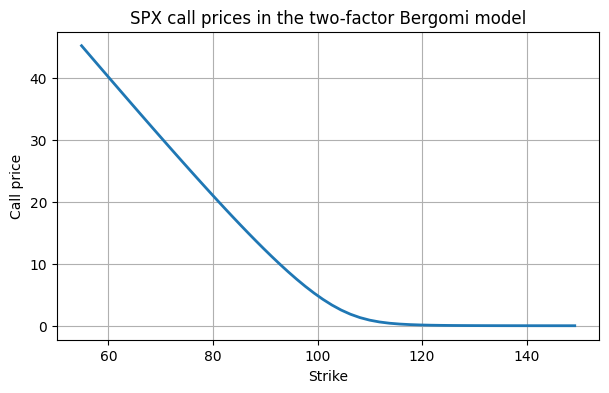

In [22]:

plt.figure()
plt.plot(strike_spx, call_prices_spx, lw=2)
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("SPX call prices in the two-factor Bergomi model")
plt.show()

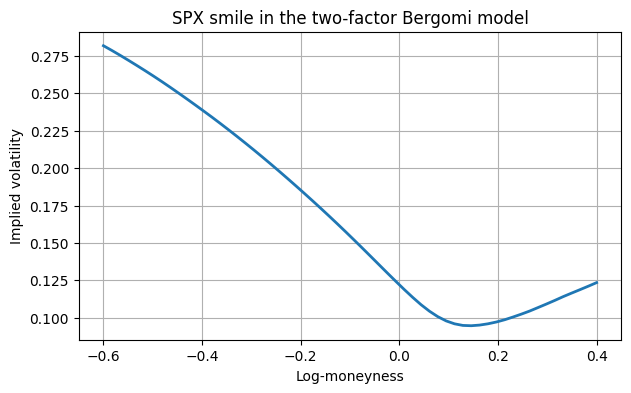

In [23]:

plt.figure()
plt.plot(lm_spx, iv_spx, lw=2)
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title("SPX smile in the two-factor Bergomi model")
plt.show()

**Comment.**  
The resulting smile is strongly equity-like:
- high implied vol on the left wing,
- lower implied vol on the right wing,
- negative skew coming from the negative spot/volatility correlations.

## 2.5 Parameter impact on the SPX smile

We vary one parameter at a time and keep the others at their base values.

### Qualitative expectations

- Larger **vol-of-vol $\omega$**: more curvature / skew magnitude.
- Different **$\theta$**: changes the balance between fast and slow variance factors.
- More negative **$\rho_{S1}$** or **$\rho_{S2}$**: steeper equity skew.
- Larger **$\rho_{12}$**: stronger comovement of the two variance factors, hence stronger effective variance-of-variance.
- Different **maturity $T$**: changes the averaging horizon and therefore the shape of the smile.

In [24]:

def bergomi_spx_smile(
    vov=4.0, k_1=20.0, k_2=1.5, theta=0.75, rho_sx1=-0.8, rho_sx2=-0.7, rho_x1x2=0.7,
    xi_0=0.025, T=1.0, S_0=100.0, n_steps=300, N_sims=40_000,
    lm=np.linspace(-0.4, 0.3, 20), seed=123
):
    ST = two_factor_bergomi_mc(
        vov=vov, k_1=k_1, k_2=k_2, theta=theta, rho_sx1=rho_sx1, rho_sx2=rho_sx2,
        rho_x1x2=rho_x1x2, xi_0=xi_0, T=T, S_0=S_0, n_steps=n_steps, N_sims=N_sims, seed=seed
    )
    K = S_0 * np.exp(lm)
    prices = np.maximum(ST[None, :] - K[:, None], 0.0).mean(axis=1)
    iv = blackscholes_impv(K, T, S_0, prices, callput="call")
    return K, iv

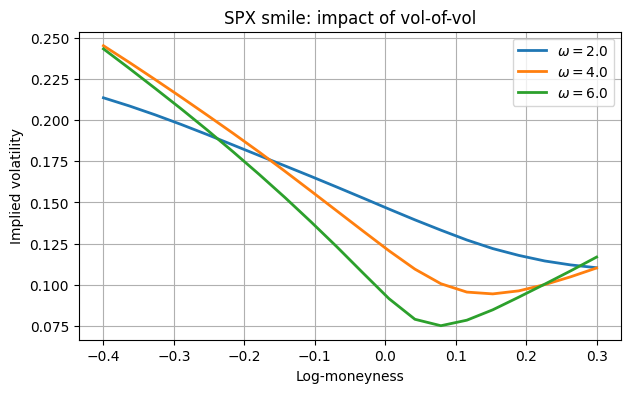

In [25]:

plt.figure()
for vov in [2.0, 4.0, 6.0]:
    _, iv = bergomi_spx_smile(vov=vov, seed=int(100 * vov))
    plt.plot(np.linspace(-0.4, 0.3, 20), iv, lw=2, label=fr"$\omega={vov}$")
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title("SPX smile: impact of vol-of-vol")
plt.legend()
plt.show()

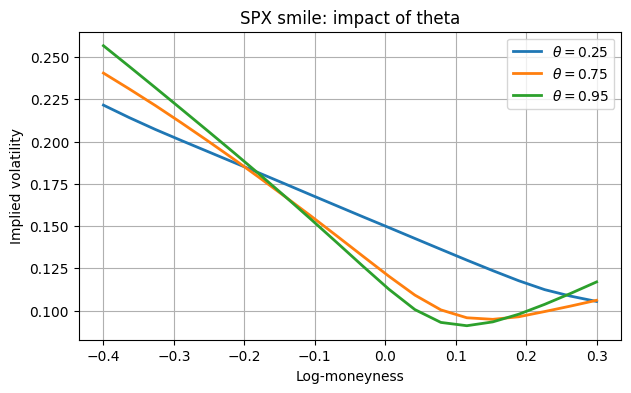

In [26]:

plt.figure()
for theta in [0.25, 0.75, 0.95]:
    _, iv = bergomi_spx_smile(theta=theta, seed=int(1000 * theta))
    plt.plot(np.linspace(-0.4, 0.3, 20), iv, lw=2, label=fr"$\theta={theta}$")
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title("SPX smile: impact of theta")
plt.legend()
plt.show()

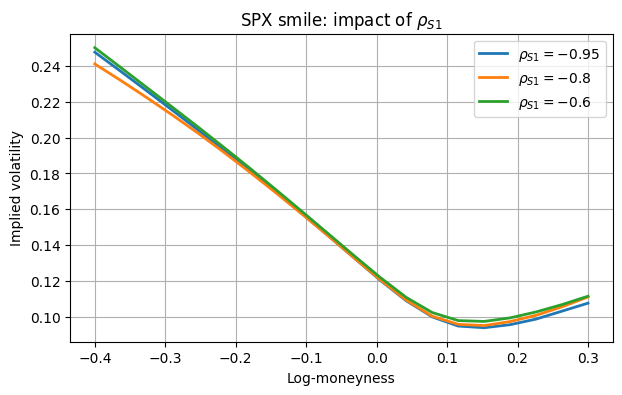

In [27]:
plt.figure()
for rho_sx1 in [-0.95, -0.80, -0.60]:
    _, iv = bergomi_spx_smile(rho_sx1=rho_sx1, seed=int(1000 * (rho_sx1 + 1.2)))
    plt.plot(np.linspace(-0.4, 0.3, 20), iv, lw=2, label=fr"$\rho_{{S1}}={rho_sx1}$")
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title(r"SPX smile: impact of $\rho_{S1}$")
plt.legend()
plt.show()

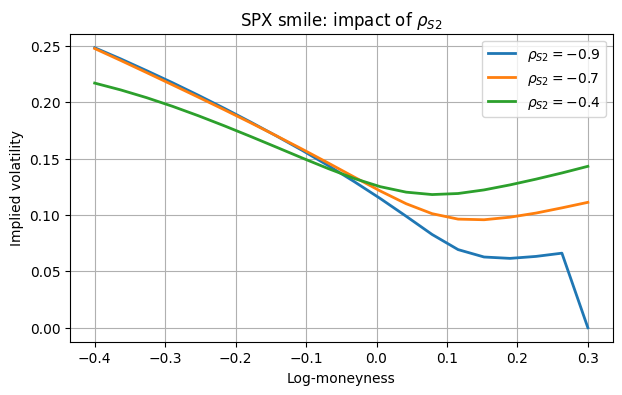

In [28]:
plt.figure()
for rho_sx2 in [-0.90, -0.70, -0.40]:
    _, iv = bergomi_spx_smile(rho_sx2=rho_sx2, seed=int(1000 * (rho_sx2 + 1.3)))
    plt.plot(np.linspace(-0.4, 0.3, 20), iv, lw=2, label=fr"$\rho_{{S2}}={rho_sx2}$")
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title(r"SPX smile: impact of $\rho_{S2}$")
plt.legend()
plt.show()

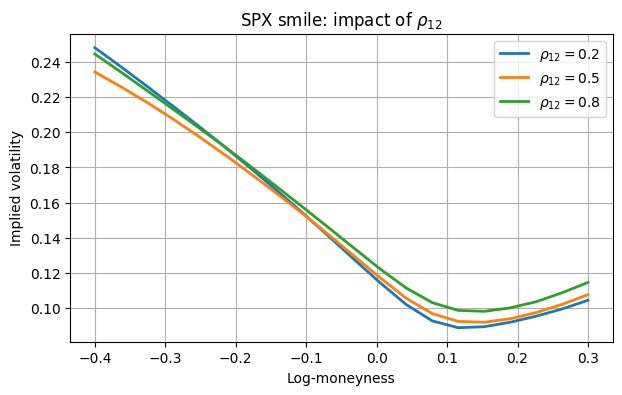

In [29]:
plt.figure()
for rho_x1x2 in [0.2, 0.5, 0.8]:
    _, iv = bergomi_spx_smile(rho_x1x2=rho_x1x2, seed=int(1000 * rho_x1x2))
    plt.plot(np.linspace(-0.4, 0.3, 20), iv, lw=2, label=fr"$\rho_{{12}}={rho_x1x2}$")
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title(r"SPX smile: impact of $\rho_{12}$")
plt.legend()
plt.show()

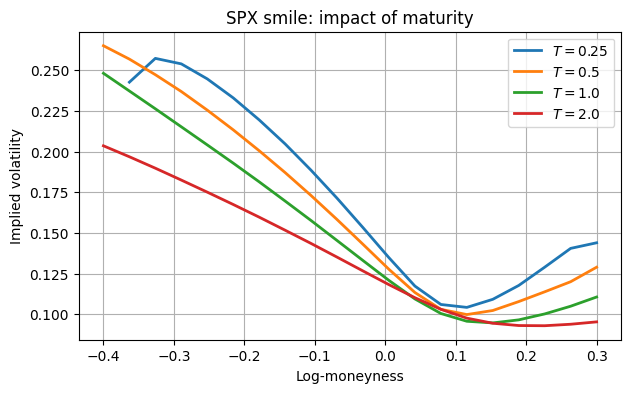

In [30]:

plt.figure()
for T in [0.25, 0.5, 1.0, 2.0]:
    _, iv = bergomi_spx_smile(T=T, n_steps=max(200, int(300 * T)), seed=int(100 * T + 7))
    plt.plot(np.linspace(-0.4, 0.3, 20), iv, lw=2, label=fr"$T={T}$")
plt.xlabel("Log-moneyness")
plt.ylabel("Implied volatility")
plt.title("SPX smile: impact of maturity")
plt.legend()
plt.show()

**Comment.**  
The numerical experiments support the standard interpretation:
- increasing $\omega$ steepens the smile/skew,
- changing $\theta$ shifts importance from the fast to the slow factor,
- more negative spot/volatility correlations make the left skew steeper,
- larger $\rho_{12}$ typically amplifies the variance-factor effect,
- maturity changes both curvature and skew through horizon averaging.

## 2.6 VIX futures and VIX options

### Martingale proof for $\xi_t^u$

Fix $u>0$.
The process
$$
x_t^u = \alpha_\theta\Big((1-\theta)e^{-k_1(u-t)}X_t^1+\theta e^{-k_2(u-t)}X_t^2\Big),\qquad 0\le t\le u,
$$
is a centered Gaussian martingale in $t$ with quadratic variation $\chi(t,u)$.
Therefore
$$
\exp\left(\omega x_t^u-\frac{\omega^2}{2}\chi(t,u)\right)
$$
is a true martingale.
Since $\xi_0^u$ is deterministic,
$$
\xi_t^u=\xi_0^u\exp\left(\omega x_t^u-\frac{\omega^2}{2}\chi(t,u)\right)
$$
is a martingale in $t$ for fixed $u$.

### Conditional expectation identity

Let $\sigma_u^2:=\xi_u^u$. Then for $T\le u$,
$$
\xi_T^u = \mathbb E[\xi_u^u\mid\mathcal F_T] = \mathbb E[\sigma_u^2\mid\mathcal F_T].
$$

### VIX formula

By definition,
$$
\text{VIX}_T^2
=
\frac1\tau \mathbb E\left[\int_T^{T+\tau}\sigma_u^2\,du\;\middle|\;\mathcal F_T\right],
\qquad \tau=\frac{30}{365}.
$$
Using Fubini and the previous identity:
$$
\boxed{
\text{VIX}_T^2
=
\frac1\tau\int_T^{T+\tau}\xi_T^u\,du.
}
$$

### Explicit function $\psi(T,X_T^1,X_T^2)$

At time $T$,
$$
x_T^u
=
\alpha_\theta\Big((1-\theta)e^{-k_1(u-T)}X_T^1+\theta e^{-k_2(u-T)}X_T^2\Big),
$$
so
$$
\xi_T^u
=
\xi_0^u
\exp\left(
\omega \alpha_\theta\big((1-\theta)e^{-k_1(u-T)}X_T^1+\theta e^{-k_2(u-T)}X_T^2\big)
-\frac{\omega^2}{2}\chi(T,u)
\right).
$$
Therefore
$$
\boxed{
\psi(T,x_1,x_2)
=
\left[
\frac1\tau
\int_T^{T+\tau}
\xi_0^u
\exp\left(
\omega \alpha_\theta\big((1-\theta)e^{-k_1(u-T)}x_1+\theta e^{-k_2(u-T)}x_2\big)
-\frac{\omega^2}{2}\chi(T,u)
\right)\,du
\right]^{1/2}.
}
$$

If $\xi_0^u\equiv \xi_0$ is constant, it factors out of the integral.

### Why Gauss-Hermite quadrature works so well

$(X_T^1,X_T^2)$ is a centered Gaussian vector with covariance matrix
$$
\Sigma_T=
\begin{bmatrix}
\operatorname{Var}(X_T^1) & \operatorname{Cov}(X_T^1,X_T^2)\\
\operatorname{Cov}(X_T^1,X_T^2) & \operatorname{Var}(X_T^2)
\end{bmatrix}.
$$
After a Cholesky factorization of $\Sigma_T$, the price
$$
\mathbb E[h(\text{VIX}_T)]
=
\mathbb E[h(\psi(T,X_T^1,X_T^2))]
$$
becomes a two-dimensional Gaussian integral. Gauss-Hermite quadrature converges very rapidly because the integrand is smooth.

In [31]:

def vix_distribution_gh(T, vov, k1, k2, theta, rho12, xi0, n_gh=20, tau=30/365, n_u=64):
    """
    Compute VIX_T on a two-dimensional Gauss-Hermite grid and return
    both the grid and the associated quadrature weights.
    """
    Sigma = np.array(
        [
            [cov_ou(k1, k1, 1.0, T), cov_ou(k1, k2, rho12, T)],
            [cov_ou(k1, k2, rho12, T), cov_ou(k2, k2, 1.0, T)],
        ],
        dtype=float,
    )
    L = np.linalg.cholesky(Sigma + 1e-18 * np.eye(2))

    gh_x, gh_w = hermgauss(n_gh)
    z1, z2 = np.meshgrid(np.sqrt(2.0) * gh_x, np.sqrt(2.0) * gh_x, indexing="ij")
    weights = np.outer(gh_w, gh_w) / np.pi

    X1 = L[0, 0] * z1
    X2 = L[1, 0] * z1 + L[1, 1] * z2

    lg_x, lg_w = np.polynomial.legendre.leggauss(n_u)
    us = T + 0.5 * (lg_x + 1.0) * tau
    wu = 0.5 * tau * lg_w

    alpha = bergomi_alpha(theta, rho12)
    chi_vals = chi_general(T, us, k1, k2, theta, rho12, alpha)

    exp1 = np.exp(-k1 * (us - T))
    exp2 = np.exp(-k2 * (us - T))
    xTu = alpha * ((1.0 - theta) * X1[..., None] * exp1 + theta * X2[..., None] * exp2)

    integrand = xi0 * np.exp(vov * xTu - 0.5 * vov**2 * chi_vals)
    vix2 = np.tensordot(integrand, wu, axes=([2], [0])) / tau
    vix = np.sqrt(vix2)

    return vix, weights


def vix_future_and_options(T, vov, k1, k2, theta, rho12, xi0, n_gh=20, tau=30/365, n_u=64, lm_grid=None):
    """
    Price the VIX future and VIX calls using 2D Gauss-Hermite quadrature.
    """
    vix_grid, weights = vix_distribution_gh(T, vov, k1, k2, theta, rho12, xi0, n_gh=n_gh, tau=tau, n_u=n_u)
    F = np.sum(weights * vix_grid)

    if lm_grid is None:
        return F, None, None, None

    lm_grid = np.asarray(lm_grid, dtype=float)
    K = F * np.exp(lm_grid)
    prices = np.array([np.sum(weights * np.maximum(vix_grid - strike, 0.0)) for strike in K])
    iv = black_impv(K, T, F, prices, callput="call")
    return F, K, prices, iv

## 2.7 Numerical pricing of VIX futures and VIX options

We use the base Bergomi parameters and maturities
$$
T\in\left\{\frac1{12},\frac2{12},\frac3{12},\frac4{12}\right\}.
$$
For VIX calls, strikes are taken with log-moneyness from $-0.2$ to $2.5$ relative to the VIX future.

In [32]:

vov = 4.0
k_1 = 20.0
k_2 = 1.5
theta = 0.75
rho_sx1, rho_sx2, rho_x1x2 = -0.8, -0.7, 0.7
xi_0 = 0.025

maturity_list = [1/12, 2/12, 3/12, 4/12]
gh_points_list = [10, 20, 30, 50]

future_rows = []
for T in maturity_list:
    row = {"T": T}
    for n_gh in gh_points_list:
        F, _, _, _ = vix_future_and_options(T, vov, k_1, k_2, theta, rho_x1x2, xi_0, n_gh=n_gh)
        row[f"VIX future ({n_gh} pts)"] = F
    future_rows.append(row)

vix_future_table = pd.DataFrame(future_rows)
vix_future_table

,T,VIX future (10 pts),VIX future (20 pts),VIX future (30 pts),VIX future (50 pts)
0,0.083333,0.143929,0.143929,0.143929,0.143929
1,0.166667,0.134728,0.134728,0.134728,0.134728
2,0.250000,0.128115,0.128115,0.128115,0.128115
3,0.333333,0.123214,0.123214,0.123214,0.123214


**Observation on quadrature convergence.**  
The future prices should be essentially identical for 10, 20, 30 and 50 points.
This shows how effective Gauss-Hermite quadrature is in this setting.
For options, 30 or 50 points are still preferable, especially in the far OTM region, but convergence remains very fast.

In [33]:

lm_vix = np.linspace(-0.2, 2.5, 25)

vix_smiles = {}
vix_futures = {}

for T in maturity_list:
    F, K, prices, iv = vix_future_and_options(
        T, vov, k_1, k_2, theta, rho_x1x2, xi_0, n_gh=50, lm_grid=lm_vix
    )
    vix_futures[T] = F
    vix_smiles[T] = (K, prices, iv)

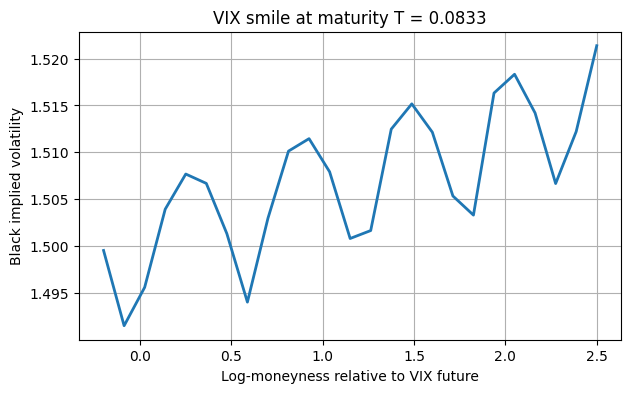

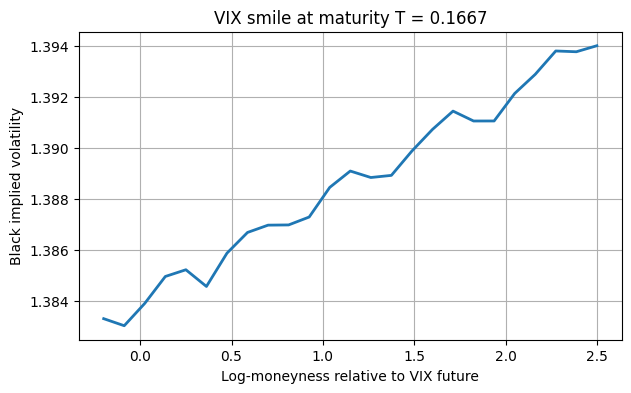

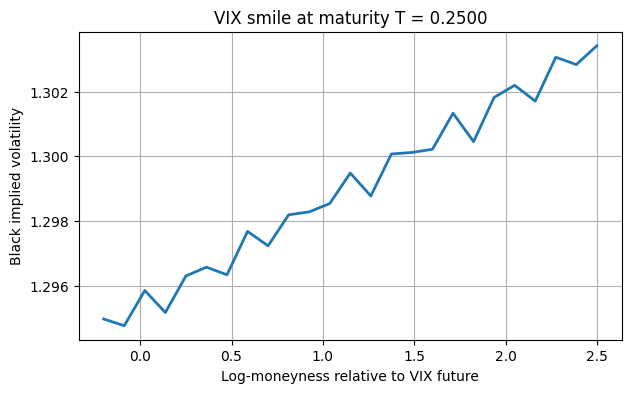

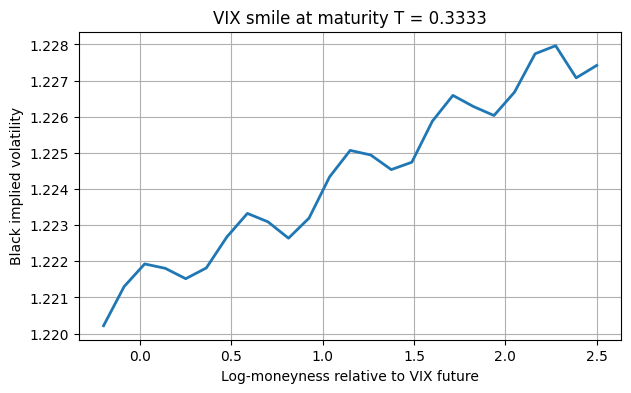

In [34]:

for T in maturity_list:
    plt.figure()
    K, prices, iv = vix_smiles[T]
    plt.plot(np.log(K / vix_futures[T]), iv, lw=2)
    plt.xlabel("Log-moneyness relative to VIX future")
    plt.ylabel("Black implied volatility")
    plt.title(f"VIX smile at maturity T = {T:.4f}")
    plt.show()

**Comment.**  
The VIX implied volatilities are typically very high in Bergomi-type models.
This is not a numerical bug: VIX is itself a volatility-like underlying, so its distribution can be very dispersed.

## 2.8 Impact of the vol-of-vol on VIX futures and VIX implied volatilities

Increasing $\omega$ widens the distribution of future variance.
This tends to increase VIX option prices strongly.
For the VIX future, however, the effect is more subtle because VIX involves a square root:
$$
\text{VIX}_T = \sqrt{\text{average future variance}},
$$
and the square root is concave.
So the VIX future level need not increase with $\omega$.

In [35]:

vov_values = [2.0, 3.0, 4.0, 5.0]
rows = []

for vv in vov_values:
    F, K, prices, iv = vix_future_and_options(
        1/12, vv, k_1, k_2, theta, rho_x1x2, xi_0, n_gh=50, lm_grid=np.linspace(-0.2, 1.5, 15)
    )
    atm_index = np.argmin(np.abs(np.log(K / F)))
    rows.append(
        {
            "vov": vv,
            "VIX future (1m)": F,
            "ATM VIX implied vol": iv[atm_index],
        }
    )

pd.DataFrame(rows)

,vov,VIX future (1m),ATM VIX implied vol
0,2.0,0.154438,0.746580
1,3.0,0.149966,1.120143
2,4.0,0.143929,1.491143
3,5.0,0.136534,1.868051


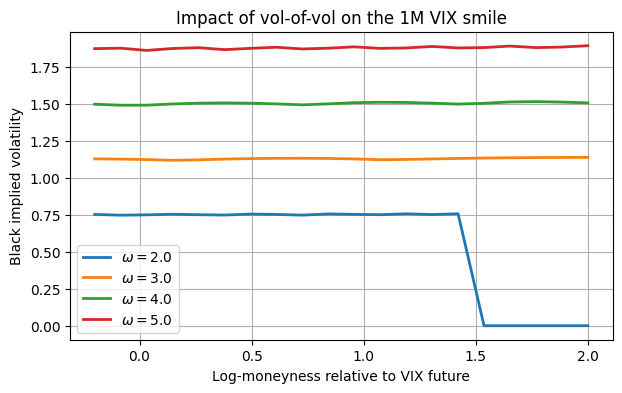

In [36]:

plt.figure()
for vv in vov_values:
    F, K, prices, iv = vix_future_and_options(
        1/12, vv, k_1, k_2, theta, rho_x1x2, xi_0, n_gh=50, lm_grid=np.linspace(-0.2, 2.0, 20)
    )
    plt.plot(np.log(K / F), iv, lw=2, label=fr"$\omega={vv}$")
plt.xlabel("Log-moneyness relative to VIX future")
plt.ylabel("Black implied volatility")
plt.title("Impact of vol-of-vol on the 1M VIX smile")
plt.legend()
plt.show()

**Comment.**  
The numerical experiment typically shows:
- VIX option implied vols increase strongly with $\omega$,
- the VIX future may decrease as $\omega$ increases because the concavity of the square root dominates the increase in variance dispersion.

## 2.9 One-factor Bergomi: impact of mean reversion on the VIX smile

Set $\theta=0$ and vary
$$
k_1\in\{1,5,10,30,60,100\}.
$$

### Expected behavior

When $\theta=0$, the VIX depends on one factor only.
As $k_1$ increases, the factor decays faster over the 30-day forward window, so VIX becomes less sensitive to the current factor $X_T^1$.
Therefore VIX implied volatilities should fall with $k_1$.

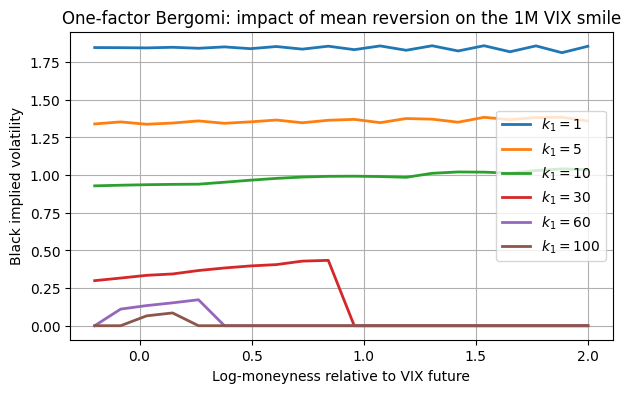

,k_1,VIX future (1m),ATM VIX implied vol
0,1,0.137260,1.844359
1,5,0.146584,1.337517
2,10,0.152308,0.936126
3,30,0.157398,0.334546
4,60,0.158007,0.133593
5,100,0.158090,0.065569


In [37]:

k_values = [1, 5, 10, 30, 60, 100]
rows = []

plt.figure()
for k in k_values:
    F, K, prices, iv = vix_future_and_options(
        1/12, 4.0, k, 1.0, 0.0, 0.0, xi_0, n_gh=50, lm_grid=np.linspace(-0.2, 2.0, 20)
    )
    atm_index = np.argmin(np.abs(np.log(K / F)))
    rows.append({"k_1": k, "VIX future (1m)": F, "ATM VIX implied vol": iv[atm_index]})
    plt.plot(np.log(K / F), iv, lw=2, label=fr"$k_1={k}$")

plt.xlabel("Log-moneyness relative to VIX future")
plt.ylabel("Black implied volatility")
plt.title("One-factor Bergomi: impact of mean reversion on the 1M VIX smile")
plt.legend()
plt.show()

pd.DataFrame(rows)

**Comment.**  
The numerical pattern is very clear:
- larger $k_1$ leads to much lower VIX implied volatilities,
- the VIX future level can move slightly, but the dominant effect is the strong reduction in option smile intensity.

This matches the theory: fast mean reversion makes the future variance strip much less sensitive to the current factor over the 30-day VIX window.

---

# Final conclusions

1. **SLV particle calibration**  
   The leverage function must satisfy
   $$
   l(t,S)^2 = \frac{\sigma_{\text{Dup}}(t,S)^2}{\mathbb E[a_t^2\mid S_t=S]}.
   $$
   The particle method estimates the conditional expectation sequentially in time and produces a leverage surface that matches the target vanilla smile.

2. **Impact of Part 1 parameters**  
   - Larger $\gamma$ increases the pure-SV smile curvature and requires a stronger leverage correction.
   - Negative $\rho$ generates the familiar equity left skew.
   - Smaller $\kappa$ makes volatility shocks more persistent and strengthens smile effects.

3. **Why SLV is useful**  
   Time-0 vanilla calibration alone does not determine forward smile dynamics.
   The forward-start spread illustrates why one wants a model with both local and stochastic volatility components.

4. **Two-factor Bergomi model**  
   The exact OU updates, combined with Euler on the log spot and the correct conditional covariance matrix, provide an efficient Monte Carlo scheme for SPX options.

5. **VIX derivatives**  
   In the Bergomi model, VIX is an explicit function of the Gaussian pair $(X_T^1,X_T^2)$.
   This makes Gauss-Hermite quadrature especially efficient for VIX futures and VIX options.

This notebook is therefore a complete worked solution to the assignment, with both the mathematical derivations and the production-quality Python implementation.